# Retail POS Exploratory Data Analysis (EDA)

This notebook explores cleaned retail POS data for trend, seasonality, product performance, and price-demand behavior.

In [1]:
# Imports and plot style
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading

In [2]:
# Locate and load cleaned dataset
candidate_paths = [
    Path('data/processed/cleaned_pos_data.csv'),
    Path('../data/processed/cleaned_pos_data.csv'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find cleaned_pos_data.csv in expected locations.')

df = pd.read_csv(data_path)
print(f'Loaded data from: {data_path.resolve()}')
print(f'Shape: {df.shape}')

Loaded data from: D:\Project\GitHub Project\Dissanayaka Super Web POS\Dissanayake-Super-Web-POS-ML-Engine\data\processed\cleaned_pos_data.csv
Shape: (812258, 13)


In [3]:
# Preview rows
df.head()

,TransactionID,Date,Time,ProductID,ProductName,Category,PricingUnit,UnitPrice,BuyingPrice,SellingPrice,Quantity,Total_LKR,Payment Method
0,TX0005400000,2021-01-01,7:47:47,PI00469,Whiskas Adult Ocean Fish Food - 500g,Pet Products,Pack,820,700,820,1,970,Cash
1,TX0005400000,2021-01-01,7:47:47,PI00097,Kotmale Milk Chocolate - 170ml,Dairy,Pack,50,45,150,3,970,Cash
2,TX0005400001,2021-01-01,8:08:33,PI03359,Precare Unisex Sandal 1 S07 Bj0003 - 1pc,Health & Beauty,Unit,5500,4600,5500,1,5980,Cash
3,TX0005400001,2021-01-01,8:08:33,PI03268,Newtro Chili Powder - 100g,Seeds & Spices,Pack,190,170,380,2,5980,Cash
4,TX0005400001,2021-01-01,8:08:33,PI00173,Denta Comfort Soft Toothbrushes - 2pcs,Health & Beauty,Unit,100,80,100,1,5980,Cash


In [4]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812258 entries, 0 to 812257
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   TransactionID   812258 non-null  object
 1   Date            320762 non-null  object
 2   Time            812258 non-null  object
 3   ProductID       812258 non-null  object
 4   ProductName     812258 non-null  object
 5   Category        812258 non-null  object
 6   PricingUnit     812258 non-null  object
 7   UnitPrice       812258 non-null  int64 
 8   BuyingPrice     812258 non-null  int64 
 9   SellingPrice    812258 non-null  int64 
 10  Quantity        812258 non-null  int64 
 11  Total_LKR       812258 non-null  int64 
 12  Payment Method  812258 non-null  object
dtypes: int64(5), object(8)
memory usage: 80.6+ MB


In [5]:
# Ensure Date is datetime
if 'Date' not in df.columns:
    raise KeyError("Required column 'Date' is missing from the dataset.")

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).copy()

# Validate Quantity column
if 'Quantity' not in df.columns:
    raise KeyError("Required column 'Quantity' is missing from the dataset.")

## 2. Daily Sales Trend
Total Quantity sold per day

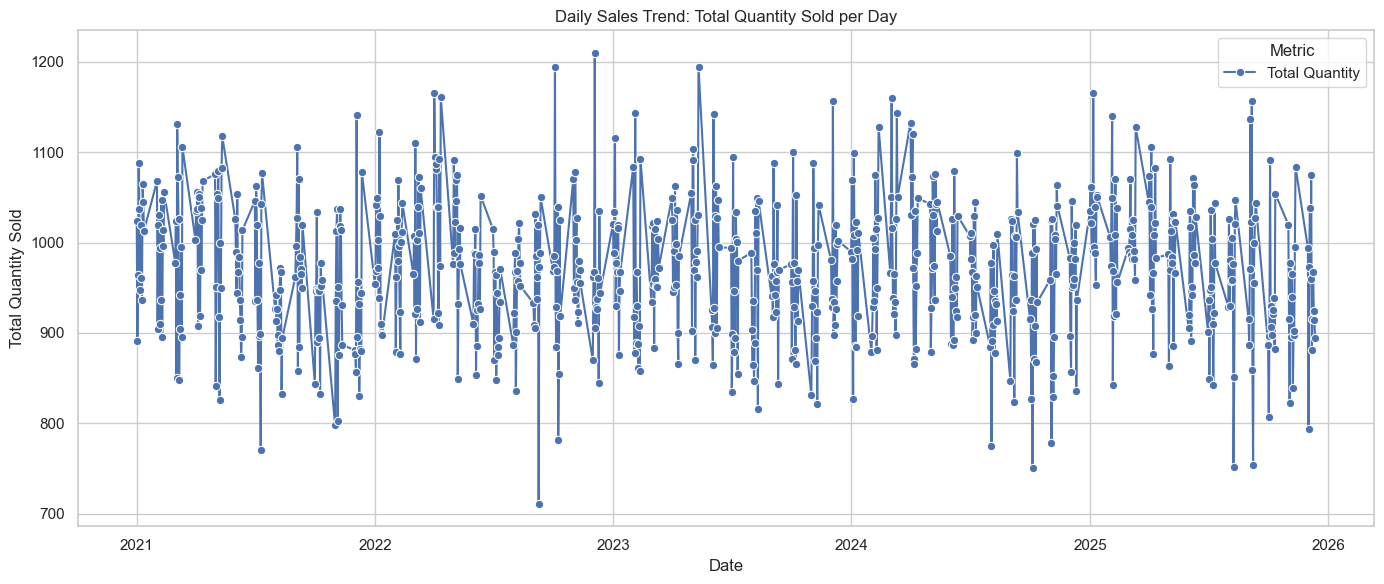

In [6]:
daily_sales = (
    df.groupby(df['Date'].dt.date)['Quantity']
    .sum()
    .reset_index(name='TotalQuantity')
)
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='Date', y='TotalQuantity', marker='o', label='Total Quantity')
plt.title('Daily Sales Trend: Total Quantity Sold per Day')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 3. Seasonality Analysis
Average sales by Day of Week (Monday-Sunday)

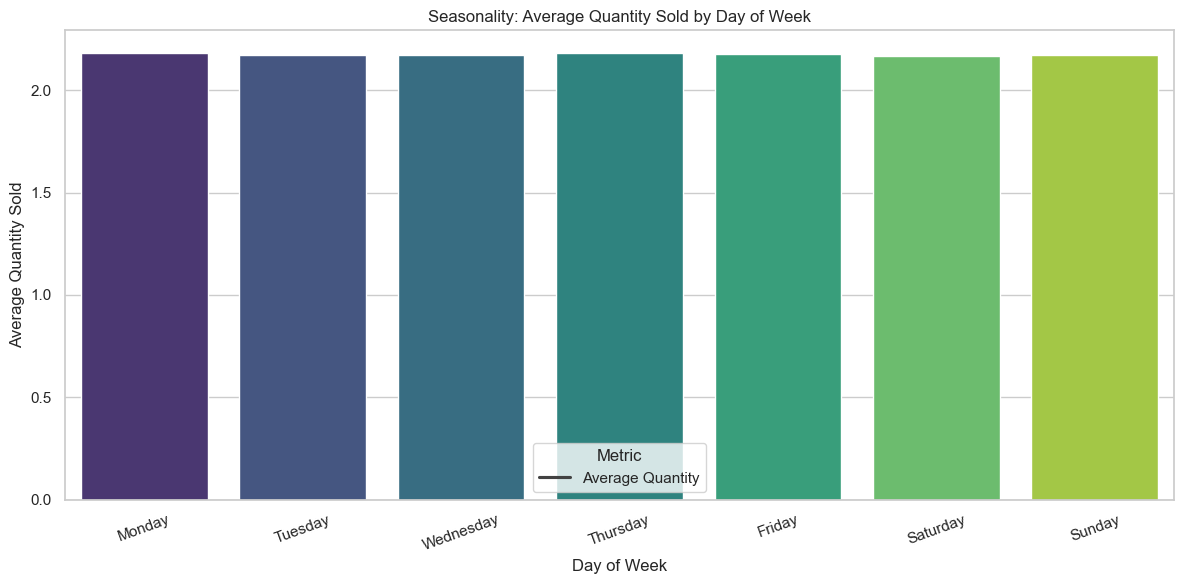

In [7]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['Date'].dt.day_name(), categories=day_order, ordered=True)
avg_sales_dow = (
    df.groupby('DayOfWeek', observed=False)['Quantity']
    .mean()
    .reset_index(name='AverageQuantity')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_sales_dow, x='DayOfWeek', y='AverageQuantity', hue='DayOfWeek', palette='viridis', dodge=False, legend=False)
plt.title('Seasonality: Average Quantity Sold by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Quantity Sold')
plt.legend(['Average Quantity'], title='Metric')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Product Performance
Top 10 products by total quantity sold

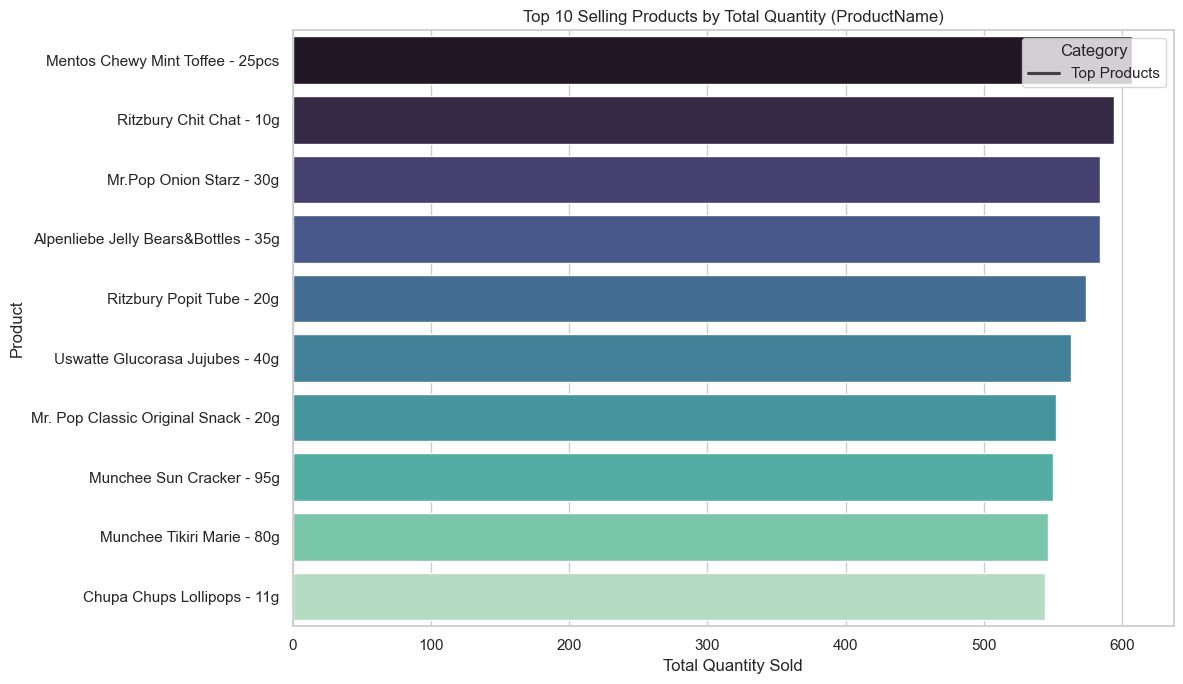

In [8]:
product_col = 'ProductName' if 'ProductName' in df.columns else 'Item_ID'
if product_col not in df.columns:
    raise KeyError("Neither 'ProductName' nor 'Item_ID' is available in the dataset.")

top_products = (
    df.groupby(product_col)['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='TotalQuantity')
)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_products, x='TotalQuantity', y=product_col, hue=product_col, palette='mako', dodge=False, legend=False)
plt.title(f'Top 10 Selling Products by Total Quantity ({product_col})')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.legend(['Top Products'], title='Category')
plt.tight_layout()
plt.show()

## 5. Price vs. Demand
Scatter plot and correlation between UnitPrice and Quantity

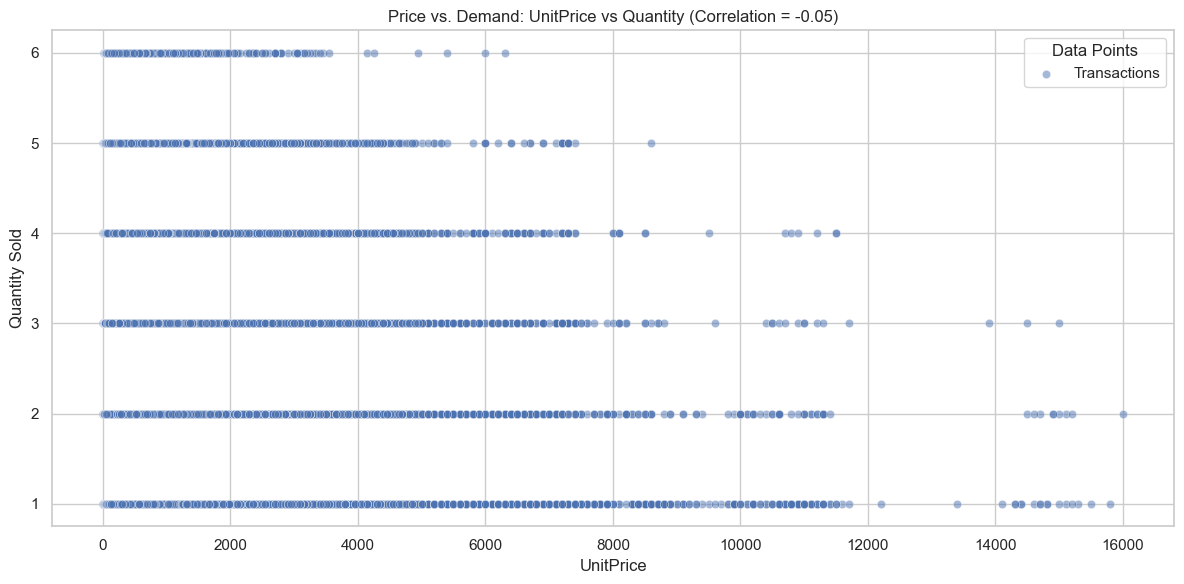

Correlation between UnitPrice and Quantity: -0.0484


In [9]:
price_col = 'UnitPrice' if 'UnitPrice' in df.columns else 'SellingPrice'
if price_col not in df.columns:
    raise KeyError("Neither 'UnitPrice' nor 'SellingPrice' is available in the dataset.")

corr_value = df[[price_col, 'Quantity']].corr().loc[price_col, 'Quantity']

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x=price_col, y='Quantity', alpha=0.5, label='Transactions')
plt.title(f'Price vs. Demand: {price_col} vs Quantity (Correlation = {corr_value:.2f})')
plt.xlabel(price_col)
plt.ylabel('Quantity Sold')
plt.legend(title='Data Points')
plt.tight_layout()
plt.show()

print(f'Correlation between {price_col} and Quantity: {corr_value:.4f}')

## 6. Feature Engineering Prep
Create Is_Weekend and Month from Date

In [10]:
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5
df['Month'] = df['Date'].dt.month

df[['Date', 'Is_Weekend', 'Month']].head()

,Date,Is_Weekend,Month
0,2021-01-01,False,1
1,2021-01-01,False,1
2,2021-01-01,False,1
3,2021-01-01,False,1
4,2021-01-01,False,1


In [11]:
# Final quick check of engineered columns and summary
print('Is_Weekend distribution:')
print(df['Is_Weekend'].value_counts(dropna=False))
print('\nMonth distribution:')
print(df['Month'].value_counts(dropna=False).sort_index())

df.head()

Is_Weekend distribution:
Is_Weekend
False    229043
True      91719
Name: count, dtype: int64

Month distribution:
Month
1     27415
2     27005
3     27492
4     27676
5     27580
6     26543
7     26113
8     25849
9     26685
10    25930
11    26106
12    26368
Name: count, dtype: int64


,TransactionID,Date,Time,ProductID,ProductName,Category,PricingUnit,UnitPrice,BuyingPrice,SellingPrice,Quantity,Total_LKR,Payment Method,DayOfWeek,Is_Weekend,Month
0,TX0005400000,2021-01-01,7:47:47,PI00469,Whiskas Adult Ocean Fish Food - 500g,Pet Products,Pack,820,700,820,1,970,Cash,Friday,False,1
1,TX0005400000,2021-01-01,7:47:47,PI00097,Kotmale Milk Chocolate - 170ml,Dairy,Pack,50,45,150,3,970,Cash,Friday,False,1
2,TX0005400001,2021-01-01,8:08:33,PI03359,Precare Unisex Sandal 1 S07 Bj0003 - 1pc,Health & Beauty,Unit,5500,4600,5500,1,5980,Cash,Friday,False,1
3,TX0005400001,2021-01-01,8:08:33,PI03268,Newtro Chili Powder - 100g,Seeds & Spices,Pack,190,170,380,2,5980,Cash,Friday,False,1
4,TX0005400001,2021-01-01,8:08:33,PI00173,Denta Comfort Soft Toothbrushes - 2pcs,Health & Beauty,Unit,100,80,100,1,5980,Cash,Friday,False,1
